In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

# ----------------------------
# Dataset
# ----------------------------
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],
})

print("Original Data")
print(df)

# ----------------------------
# 1. One-Hot Encoding (city)
# ----------------------------
city_encoded = pd.get_dummies(
    df['city'],
    prefix='city',
    drop_first=True
)

# ----------------------------
# 2. Ordinal Encoding (size)
# ----------------------------
size_map = {
    'small': 1,
    'medium': 2,
    'large': 3
}

df['size'] = df['size'].map(size_map)

# ----------------------------
# 3. Scaling (age, income)
# ----------------------------
scaler = StandardScaler()
df[['age', 'income']] = scaler.fit_transform(df[['age', 'income']])

# ----------------------------
# 4. Merge everything
# ----------------------------
final_df = pd.concat(
    [df.drop('city', axis=1), city_encoded],
    axis=1
)

print("\nFinal Preprocessed Data")
print(final_df)

Original Data
     city    size  age  income  bought
0    pune   small   25   38000       0
1   delhi   large   41   92000       1
2  mumbai  medium   33   55000       0
3    pune  medium   29   47000       0
4   delhi   small   52  120000       1
5  mumbai   large   38   76000       1
6    pune   large   46   88000       1
7   delhi   small   22   41000       0

Final Preprocessed Data
   size       age    income  bought  city_mumbai  city_pune
0     1 -1.103290 -1.158468       0        False       True
1     3  0.538816  0.819628       1        False      False
2     2 -0.282237 -0.535734       0         True      False
3     2 -0.692763 -0.828786       0        False       True
4     1  1.667764  1.845307       1        False      False
5     3  0.230921  0.233525       1         True      False
6     3  1.051974  0.673102       1        False       True
7     1 -1.411185 -1.048574       0        False      False


In [ ]:
import pandas as pd

# -----------------------------------------------------------
# 1. ONE-HOT ENCODING (on full DataFrame using columns=[])
# -----------------------------------------------------------
city_ohe = pd.get_dummies(df, columns=['city'], prefix='city')
print("One-hot encoded city:\n")
print(city_ohe)

# -----------------------------------------------------------
# 2. ORDINAL ENCODING (size → map)
# -----------------------------------------------------------
size_order = {'small': 0, 'medium': 1, 'large': 2}

df['size_code'] = df['size'].map(size_order)

print("\nOrdinal encoded size:\n")
print(df[['size', 'size_code']])

# -----------------------------------------------------------
# 3. Explanation (COMMENT)
# -----------------------------------------------------------

# Why one-hot encoding is wrong for 'size':
# Because size has a natural order (small < medium < large),
# one-hot encoding removes this order and treats all values equally.

# Why ordinal encoding is wrong for 'city':
# Because city is a nominal category (no order).
# Assigning numbers (like Pune=0, Delhi=1, Mumbai=2)
# wrongly introduces a false ranking/priority between cities.

One-hot encoded city:

   size       age    income  bought  city_delhi  city_mumbai  city_pune
0     1 -1.103290 -1.158468       0       False        False       True
1     3  0.538816  0.819628       1        True        False      False
2     2 -0.282237 -0.535734       0       False         True      False
3     2 -0.692763 -0.828786       0       False        False       True
4     1  1.667764  1.845307       1        True        False      False
5     3  0.230921  0.233525       1       False         True      False
6     3  1.051974  0.673102       1       False        False       True
7     1 -1.411185 -1.048574       0        True        False      False

Ordinal encoded size:

   size  size_code
0     1        NaN
1     3        NaN
2     2        NaN
3     2        NaN
4     1        NaN
5     3        NaN
6     3        NaN
7     1        NaN


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

income = df[['income']]   # must be 2D

# -----------------------------------------------------------
# 1. STANDARDISATION (Z-score)
# -----------------------------------------------------------
scaler_z = StandardScaler()
income_z = scaler_z.fit_transform(income)

income_z_df = pd.DataFrame(income_z, columns=['income'])

print("Standardised Income (Z-score):")
print(income_z_df.head())

print("\nMean:", income_z_df.mean()[0])
print("Std:", income_z_df.std()[0])


# -----------------------------------------------------------
# 2. MIN-MAX SCALING
# -----------------------------------------------------------
scaler_m = MinMaxScaler()
income_m = scaler_m.fit_transform(income)

income_m_df = pd.DataFrame(income_m, columns=['income'])

print("\nMin-Max Scaled Income:")
print(income_m_df.head())

print("\nMin:", income_m_df.min()[0])
print("Max:", income_m_df.max()[0])


# -----------------------------------------------------------
# 3. COMMENT (ANSWER)
# -----------------------------------------------------------

# Needs scaling:
# - KNN, K-Means, SVM (distance-based models)

# Does NOT need scaling:
# - Decision Trees, Random Forest (tree-based models)

Standardised Income (Z-score):
     income
0 -1.158468
1  0.819628
2 -0.535734
3 -0.828786
4  1.845307

Mean: -2.7755575615628914e-17
Std: 1.0690449676496976

Min-Max Scaled Income:
     income
0  0.000000
1  0.658537
2  0.207317
3  0.109756
4  1.000000

Min: 0.0
Max: 1.0


/tmp/ipykernel_698/322410820.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\nMean:", income_z_df.mean()[0])
/tmp/ipykernel_698/322410820.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Std:", income_z_df.std()[0])
/tmp/ipykernel_698/322410820.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("\nMin:", income_m_df.min()[0])
/tmp/ipykernel_698/322410820.py:33: FutureWarning: Series.__getitem__ treati

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# features and target
X = df[['age', 'income']]
y = df['bought']

# split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# create scaler
scaler = StandardScaler()

# FIT only on training data
X_train_s = scaler.fit_transform(X_train)

# ONLY transform test data
X_test_s = scaler.transform(X_test)

print('train rows:', X_train.shape[0], '| test rows:', X_test.shape[0])
print('scaler learned mean from TRAIN only:', scaler.mean_.round(1))

train rows: 6 | test rows: 2
scaler learned mean from TRAIN only: [-0.1 -0. ]


In [ ]:
# ===========================================================
# E-COMMERCE DATASET - BASIC EDA CODE
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# -----------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------
df = pd.read_csv(
    'ecommerce_customers.csv',
    parse_dates=[
        'signup_date',
        'first_order_date',
        'last_order_date'
    ]
)

# -----------------------------------------------------------
# 1. SHAPE
# -----------------------------------------------------------
print("Shape:")
print(df.shape)

# -----------------------------------------------------------
# 2. FIRST 5 ROWS
# -----------------------------------------------------------
print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------------------------------------
# 3. DATASET INFO
# -----------------------------------------------------------
print("\nDataset Info:")
print(df.info())

# -----------------------------------------------------------
# 4. SUMMARY STATISTICS
# -----------------------------------------------------------
print("\nSummary Statistics:")
print(df.describe())

# -----------------------------------------------------------
# 5. MISSING VALUES
# -----------------------------------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------------------------------------
# 6. CHURN DISTRIBUTION
# -----------------------------------------------------------
print("\nChurn Distribution:")
print(df['is_churned'].value_counts())

print("\nChurn Percentage:")
print(df['is_churned'].value_counts(normalize=True) * 100)

# -----------------------------------------------------------
# 7. NUMERICAL FEATURE DISTRIBUTIONS
# -----------------------------------------------------------
df[['age',
    'num_orders',
    'total_spend',
    'support_tickets']].hist(
        figsize=(10, 6),
        bins=20
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 8. SKEWNESS
# -----------------------------------------------------------
print("\nSkewness:")
print(
    df[['age',
        'num_orders',
        'total_spend',
        'support_tickets']]
    .skew()
)

# -----------------------------------------------------------
# 9. KURTOSIS
# -----------------------------------------------------------
print("\nKurtosis:")
print(
    df[['age',
        'num_orders',
        'total_spend',
        'support_tickets']]
    .kurt()
)

# -----------------------------------------------------------
# 10. CORRELATION MATRIX
# -----------------------------------------------------------
corr = df.select_dtypes(include=np.number).corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------------------------
# 11. CHURN VS NUMERICAL FEATURES
# -----------------------------------------------------------
num_cols = [
    'age',
    'num_orders',
    'total_spend',
    'support_tickets'
]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        x='is_churned',
        y=col,
        data=df
    )
    plt.title(f'{col} vs Churn')
    plt.show()

# -----------------------------------------------------------
# 12. CATEGORICAL COLUMN DISTRIBUTIONS
# -----------------------------------------------------------
cat_cols = [
    'gender',
    'city',
    'plan',
    'device',
    'payment_method'
]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        x=col,
        data=df
    )
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

# -----------------------------------------------------------
# 13. TOP 10 CUSTOMERS BY SPEND
# -----------------------------------------------------------
top_customers = df.nlargest(
    10,
    'total_spend'
)[['customer_id', 'total_spend']]

print("\nTop 10 Customers by Spend:")
print(top_customers)

# -----------------------------------------------------------
# 14. CHECK OUTLIERS (IQR METHOD)
# -----------------------------------------------------------
Q1 = df['total_spend'].quantile(0.25)
Q3 = df['total_spend'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['total_spend'] < lower) |
    (df['total_spend'] > upper)
]

print("\nNumber of Outliers in total_spend:")
print(outliers.shape[0])

# -----------------------------------------------------------
# 15. CHURN RATE
# -----------------------------------------------------------
churn_rate = df['is_churned'].mean() * 100

print("\nOverall Churn Rate:")
print(round(churn_rate, 2), "%")

FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_customers.csv'

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. COMBINE & BIN EXISTING COLUMNS
# -----------------------------------------------------------

fe = df.copy()

# income per age (feature engineering)
fe['income_per_age'] = (fe['income'] / fe['age']).round(0)

# age grouping (binning)
fe['age_group'] = pd.cut(
    fe['age'],
    bins=[0, 30, 45, 100],
    labels=['young', 'mid', 'senior']
)

fe[['age', 'income', 'income_per_age', 'age_group']]


# -----------------------------------------------------------
# 🔹 4B. EXTRACT FROM DATE
# -----------------------------------------------------------

dates = pd.to_datetime(['2024-01-06', '2024-03-15', '2024-07-21', '2024-12-25'])

d = pd.DataFrame({'date': dates})

d['day_of_week'] = d['date'].dt.day_name()
d['month'] = d['date'].dt.month
d['is_weekend'] = d['date'].dt.dayofweek >= 5

d

,date,day_of_week,month,is_weekend
0,2024-01-06,Saturday,1,True
1,2024-03-15,Friday,3,False
2,2024-07-21,Sunday,7,True
3,2024-12-25,Wednesday,12,False


In [ ]:
import pandas as pd

# Sample dataset (same structure as your lab)
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],
})

# LAB EXERCISE 4 — Feature Engineering
ex = df.copy()

# 1. high earner flag
median_income = ex['income'].median()
ex['high_earner'] = ex['income'] > median_income

# 2. income bins
ex['income_bucket'] = pd.cut(
    ex['income'],
    bins=3,
    labels=['low', 'mid', 'high']
)

# 3. show result
ex[['income', 'high_earner', 'income_bucket']]

,income,high_earner,income_bucket
0,38000,False,low
1,92000,True,mid
2,55000,False,low
3,47000,False,low
4,120000,True,high
5,76000,True,mid
6,88000,True,mid
7,41000,False,low


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------
# DATA
# -----------------------------------------------------------
df = pd.DataFrame({
    'age': [25, 45, 35, 29, 52, 23, 40, 60],
    'income': [30000, 90000, 60000, 45000, 120000, 25000, 70000, 150000],
    'credit_score': [650, 800, 720, 680, 850, 600, 750, 900],
    'city': ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'loan_approved': [0, 1, 1, 0, 1, 0, 1, 1]
})

# -----------------------------------------------------------
# FEATURES & TARGET
# -----------------------------------------------------------
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# -----------------------------------------------------------
# TRAIN-TEST SPLIT
# -----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------------------------------------
# COLUMN GROUPS
# -----------------------------------------------------------
num_cols = ['age', 'income', 'credit_score']
cat_cols = ['city']

# -----------------------------------------------------------
# PREPROCESSING
# -----------------------------------------------------------
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# -----------------------------------------------------------
# PIPELINE (PREPROCESS + MODEL)
# -----------------------------------------------------------
pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression())
])

# -----------------------------------------------------------
# TRAINING (FIT ONLY ON TRAIN DATA)
# -----------------------------------------------------------
pipe.fit(X_train, y_train)

# -----------------------------------------------------------
# EVALUATION (TEST DATA ONLY TRANSFORMED INSIDE PIPELINE)
# -----------------------------------------------------------
accuracy = pipe.score(X_test, y_test)

print("Test Accuracy:", round(accuracy, 2))

Test Accuracy: 1.0


Shape:
(2500, 15)

First 5 Rows:
  customer_id signup_date first_order_date last_order_date   age gender  \
0   CUST00001  2021-04-19              NaT             NaT  31.0      F   
1   CUST00002  2023-07-31              NaT             NaT  54.0      F   
2   CUST00003  2023-03-07       2023-05-22      2023-05-22  43.0  Other   
3   CUST00004  2022-06-18       2022-07-02      2022-07-02  28.0      F   
4   CUST00005  2022-06-11       2022-09-18      2024-06-15  30.0      F   

        city      plan   device payment_method  num_orders  total_spend  \
0    Chennai   Premium  Desktop           Card           0         0.00   
1  Hyderabad  Standard  Desktop         Wallet           0         0.00   
2       Pune   Premium   Mobile         Wallet           1        39.17   
3       Pune  Standard  Desktop           Card           1         2.74   
4     Mumbai  Standard   Mobile         Wallet           4       133.80   

   support_tickets  email_opt_in  is_churned  
0                2

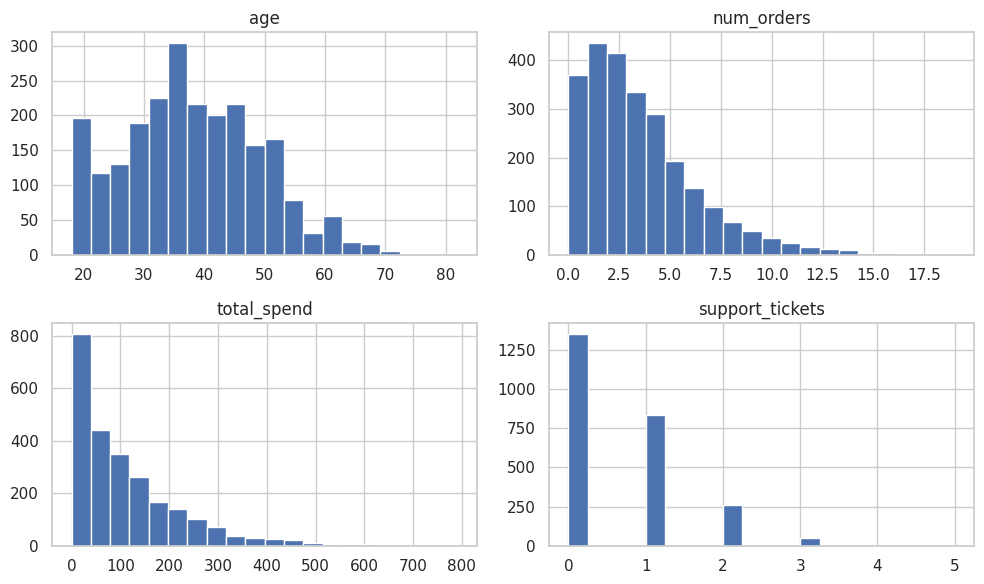


Skewness:
age                0.226028
num_orders         1.353011
total_spend        1.731732
support_tickets    1.308548
dtype: float64

Kurtosis:
age               -0.372245
num_orders         2.250484
total_spend        3.905042
support_tickets    1.957140
dtype: float64

Correlation Matrix:
                      age  num_orders  total_spend  support_tickets  \
age              1.000000    0.009322     0.006798         0.006454   
num_orders       0.009322    1.000000     0.864075         0.013193   
total_spend      0.006798    0.864075     1.000000         0.011742   
support_tickets  0.006454    0.013193     0.011742         1.000000   
email_opt_in     0.008851   -0.003310     0.001645        -0.021639   
is_churned      -0.010746   -0.282144    -0.252546         0.068880   

                 email_opt_in  is_churned  
age                  0.008851   -0.010746  
num_orders          -0.003310   -0.282144  
total_spend          0.001645   -0.252546  
support_tickets     -0.021639

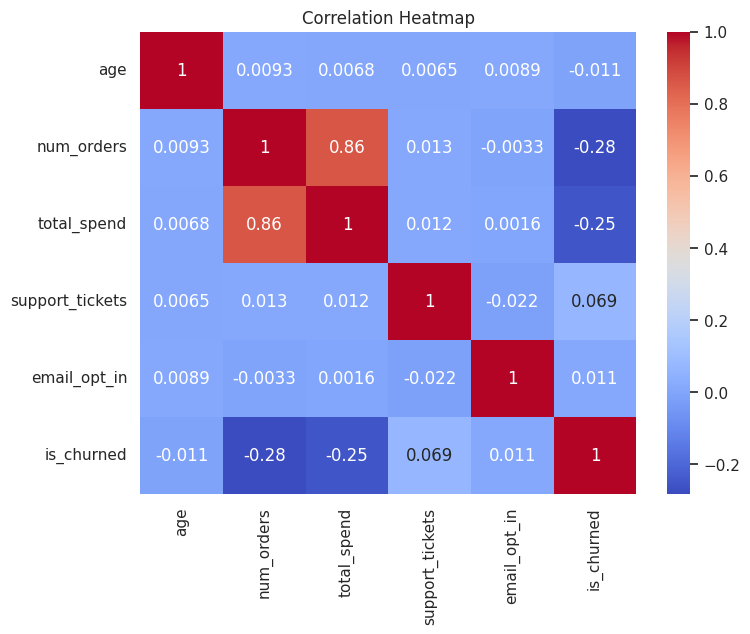

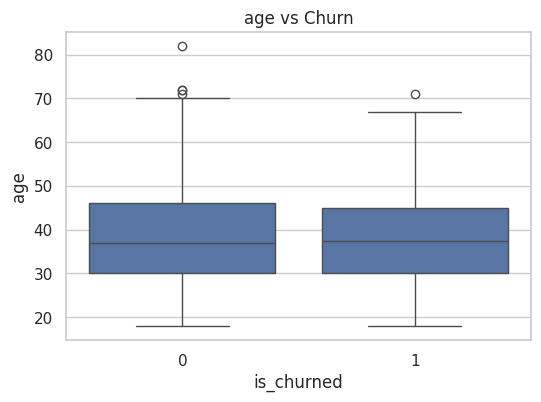

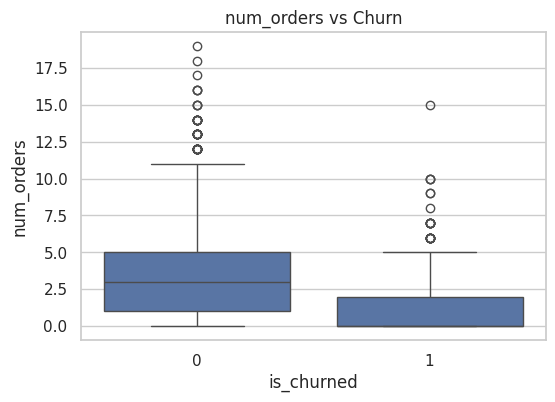

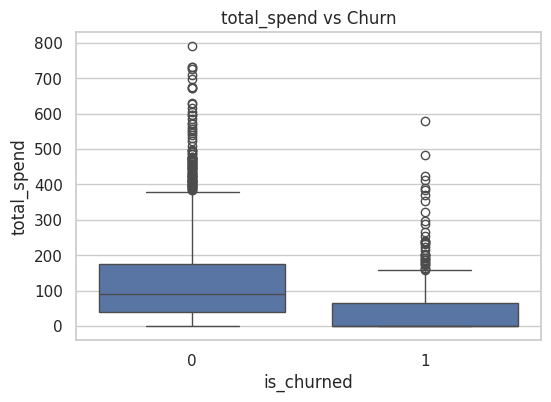

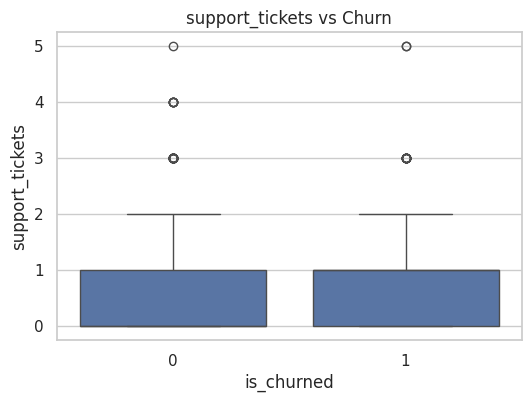

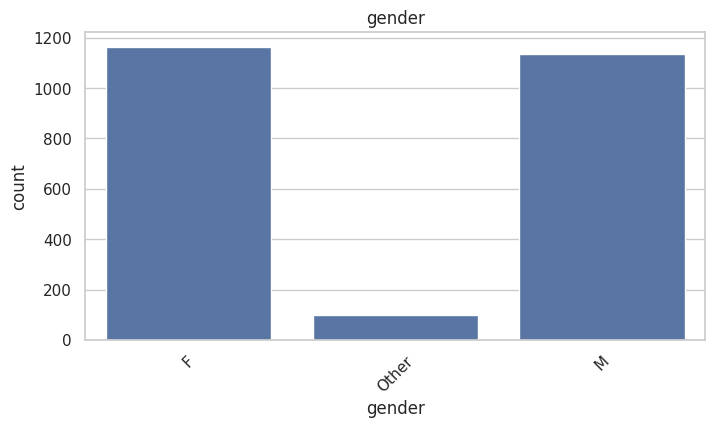

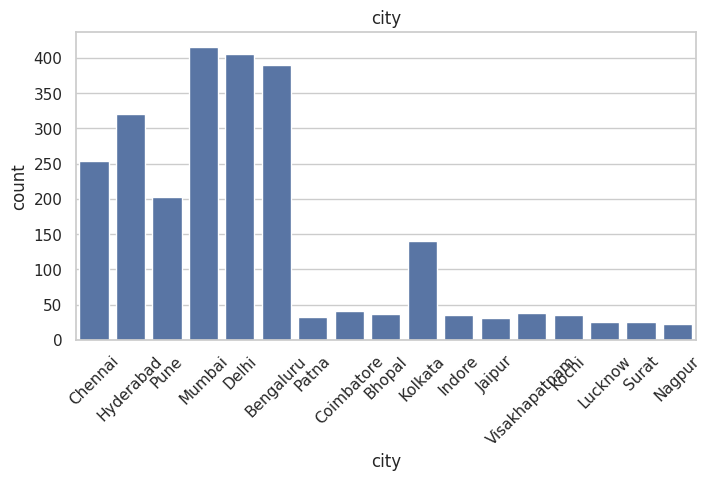

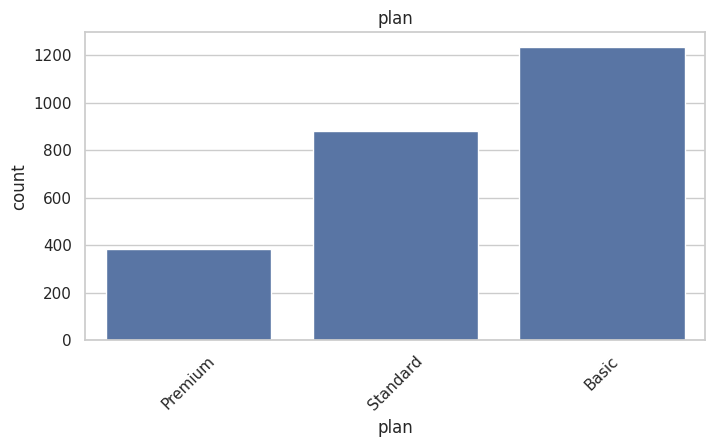

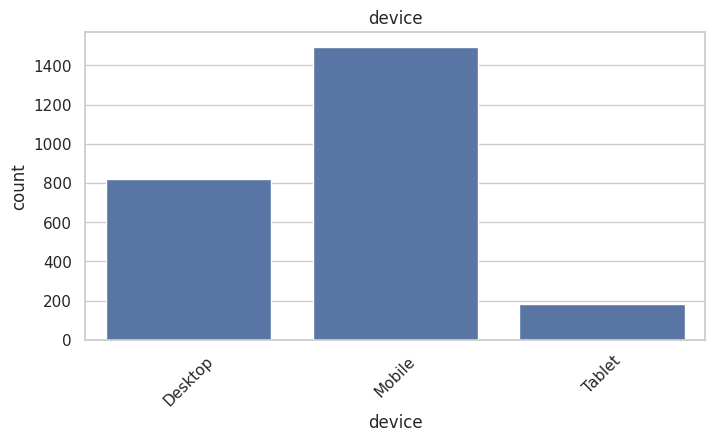

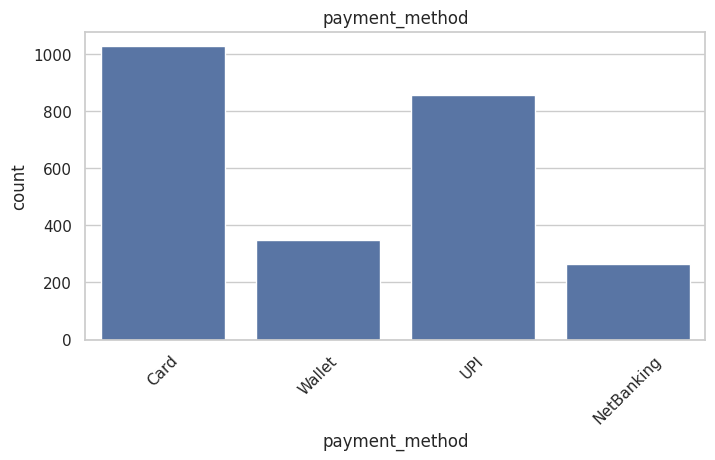


Top 10 Customers by Spend:
     customer_id  total_spend
812    CUST00813       791.37
1176   CUST01177       732.79
875    CUST00876       732.24
562    CUST00563       727.37
768    CUST00769       710.47
806    CUST00807       698.36
1101   CUST01102       675.65
794    CUST00795       671.45
411    CUST00412       671.42
1918   CUST01919       630.38

Number of Outliers in total_spend:
110

Overall Churn Rate:
16.6 %


In [ ]:
# ===========================================================
# E-COMMERCE DATASET - BASIC EDA CODE
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# -----------------------------------------------------------
# LOAD DATA
# -----------------------------------------------------------
df = pd.read_csv(
    'ecommerce_customers.csv',
    parse_dates=[
        'signup_date',
        'first_order_date',
        'last_order_date'
    ]
)

# -----------------------------------------------------------
# 1. SHAPE
# -----------------------------------------------------------
print("Shape:")
print(df.shape)

# -----------------------------------------------------------
# 2. FIRST 5 ROWS
# -----------------------------------------------------------
print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------------------------------------
# 3. DATASET INFO
# -----------------------------------------------------------
print("\nDataset Info:")
print(df.info())

# -----------------------------------------------------------
# 4. SUMMARY STATISTICS
# -----------------------------------------------------------
print("\nSummary Statistics:")
print(df.describe())

# -----------------------------------------------------------
# 5. MISSING VALUES
# -----------------------------------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------------------------------------
# 6. CHURN DISTRIBUTION
# -----------------------------------------------------------
print("\nChurn Distribution:")
print(df['is_churned'].value_counts())

print("\nChurn Percentage:")
print(df['is_churned'].value_counts(normalize=True) * 100)

# -----------------------------------------------------------
# 7. NUMERICAL FEATURE DISTRIBUTIONS
# -----------------------------------------------------------
df[['age',
    'num_orders',
    'total_spend',
    'support_tickets']].hist(
        figsize=(10, 6),
        bins=20
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 8. SKEWNESS
# -----------------------------------------------------------
print("\nSkewness:")
print(
    df[['age',
        'num_orders',
        'total_spend',
        'support_tickets']]
    .skew()
)

# -----------------------------------------------------------
# 9. KURTOSIS
# -----------------------------------------------------------
print("\nKurtosis:")
print(
    df[['age',
        'num_orders',
        'total_spend',
        'support_tickets']]
    .kurt()
)

# -----------------------------------------------------------
# 10. CORRELATION MATRIX
# -----------------------------------------------------------
corr = df.select_dtypes(include=np.number).corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------------------------------------
# 11. CHURN VS NUMERICAL FEATURES
# -----------------------------------------------------------
num_cols = [
    'age',
    'num_orders',
    'total_spend',
    'support_tickets'
]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(
        x='is_churned',
        y=col,
        data=df
    )
    plt.title(f'{col} vs Churn')
    plt.show()

# -----------------------------------------------------------
# 12. CATEGORICAL COLUMN DISTRIBUTIONS
# -----------------------------------------------------------
cat_cols = [
    'gender',
    'city',
    'plan',
    'device',
    'payment_method'
]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        x=col,
        data=df
    )
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

# -----------------------------------------------------------
# 13. TOP 10 CUSTOMERS BY SPEND
# -----------------------------------------------------------
top_customers = df.nlargest(
    10,
    'total_spend'
)[['customer_id', 'total_spend']]

print("\nTop 10 Customers by Spend:")
print(top_customers)

# -----------------------------------------------------------
# 14. CHECK OUTLIERS (IQR METHOD)
# -----------------------------------------------------------
Q1 = df['total_spend'].quantile(0.25)
Q3 = df['total_spend'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['total_spend'] < lower) |
    (df['total_spend'] > upper)
]

print("\nNumber of Outliers in total_spend:")
print(outliers.shape[0])

# -----------------------------------------------------------
# 15. CHURN RATE
# -----------------------------------------------------------
churn_rate = df['is_churned'].mean() * 100

print("\nOverall Churn Rate:")
print(round(churn_rate, 2), "%")